# 📚 Byte Pair Encoding (BPE) Algorithm: A Step-by-Step Explanation

Welcome! In this notebook, we'll implement BPE from scratch to understand how tokenizers like GPT-4, Llama, and others convert text into numbers. We'll build it piece by piece, visualizing each step.

## 🎯 Learning Objectives
- Understand why we need tokenization
- Learn the BPE algorithm intuitively
- Implement BPE from scratch
- Visualize the merge process

In [1]:
# Import our dependencies
import re
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import networkx as nx

plt.style.use('seaborn-v0_8')
print("✅ Imports complete!")

✅ Imports complete!


## 📖 What is Byte Pair Encoding?

BPE was originally a data compression algorithm, but it was adapted for NLP tokenization by Sennrich et al. (2016). The core idea:

1. Start with individual characters
2. Iteratively merge the most frequent pair of adjacent tokens
3. Build a vocabulary of subword units

This allows the model to handle:
- ✅ Common words as single tokens
- ✅ Rare words as combinations of subwords
- ✅ Unknown words at inference time

## Step 1: Pre-tokenization

Before BPE, we need to split our text into words. We'll use a simplified version of GPT-2's regex pattern.

In [2]:
def pre_tokenize(text):
    """Split text into words using regex."""
    # GPT-2 pattern: matches letters, numbers, punctuation, and spaces
    pattern = r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+"""
    
    # For simplicity, we'll use a basic pattern
    words = re.findall(r"\w+|[^\w\s]", text.lower())
    return words

# Example
sample_text = "I love programming! It's fascinating."
words = pre_tokenize(sample_text)
print(f"Original text: '{sample_text}'")
print(f"Pre-tokenized words: {words}")

Original text: 'I love programming! It's fascinating.'
Pre-tokenized words: ['i', 'love', 'programming', '!', 'it', "'", 's', 'fascinating', '.']


## Step 2: Initialize Vocabulary

We start with individual characters and add a special end-of-word marker.

In [3]:
def get_initial_vocab(words):
    """Create initial vocabulary with character frequencies."""
    vocab = Counter()
    
    for word in words:
        # Add each character with a word boundary marker
        tokenized_word = ' '.join(list(word)) + ' </w>'
        vocab[tokenized_word] += 1
    
    return vocab

# Test with a small corpus
corpus = ["low", "lower", "newest", "newer"]
initial_vocab = get_initial_vocab(corpus)

print("Initial vocabulary (with frequencies):")
for word, freq in initial_vocab.items():
    print(f"  {word:15} → {freq}")

Initial vocabulary (with frequencies):
  l o w </w>      → 1
  l o w e r </w>  → 1
  n e w e s t </w> → 1
  n e w e r </w>  → 1


## Step 3: Count Pair Frequencies

Now we need to count how often each pair of adjacent symbols occurs.

In [4]:
def get_pair_frequencies(vocab):
    """Count frequencies of adjacent symbol pairs."""
    pairs = defaultdict(int)
    
    for word, freq in vocab.items():
        symbols = word.split()
        
        for i in range(len(symbols) - 1):
            pair = (symbols[i], symbols[i+1])
            pairs[pair] += freq
    
    return pairs

pairs = get_pair_frequencies(initial_vocab)

print("Pair frequencies:")
for pair, freq in sorted(pairs.items(), key=lambda x: -x[1]):
    print(f"  {pair[0]},{pair[1]} → {freq}")

Pair frequencies:
  w,e → 3
  l,o → 2
  o,w → 2
  e,r → 2
  r,</w> → 2
  n,e → 2
  e,w → 2
  w,</w> → 1
  e,s → 1
  s,t → 1
  t,</w> → 1


## Step 4: Implement the Merge Operation

This is the core of BPE - merging the most frequent pair.

In [5]:
def merge_vocab(pair, vocab):
    """Merge all occurrences of a pair in the vocabulary."""
    new_vocab = {}
    merged_token = ''.join(pair)
    
    for word in vocab:
        # Replace the pair with merged token
        symbols = word.split()
        new_symbols = []
        i = 0
        
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i+1] == pair[1]:
                new_symbols.append(merged_token)
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        
        new_word = ' '.join(new_symbols)
        new_vocab[new_word] = vocab[word]
    
    return new_vocab

# Visualize the merge
most_frequent = max(pairs.items(), key=lambda x: x[1])
print(f"Merging most frequent pair: {most_frequent[0][0]},{most_frequent[0][1]}")

merged_vocab = merge_vocab(most_frequent[0], initial_vocab)

print("\nAfter merge:")
for word, freq in merged_vocab.items():
    print(f"  {word:15} → {freq}")

Merging most frequent pair: w,e

After merge:
  l o w </w>      → 1
  l o we r </w>   → 1
  n e we s t </w> → 1
  n e we r </w>   → 1


## Step 5: Complete BPE Training Loop

Now let's put it all together in a complete training function.

In [6]:
class SimpleBPETokenizer:
    """A simple BPE tokenizer implementation."""
    
    def __init__(self, num_merges=10):
        self.num_merges = num_merges
        self.merges = []
        self.vocab = {}
        
    def train(self, corpus):
        """Train BPE on the given corpus."""
        # Step 1: Initialize vocabulary
        vocab = self._get_initial_vocab(corpus)
        
        print(f"Initial vocabulary size: {len(vocab)}")
        print("Starting BPE training...")
        
        # Step 2: Iteratively merge
        for i in range(self.num_merges):
            pairs = self._get_pair_frequencies(vocab)
            
            if not pairs:
                break
                
            # Find most frequent pair
            best_pair = max(pairs.items(), key=lambda x: x[1])[0]
            self.merges.append(best_pair)
            
            # Merge
            vocab = self._merge_vocab(best_pair, vocab)
            
            print(f"Merge {i+1}: {best_pair[0]}+{best_pair[1]} → '{''.join(best_pair)}'")
        
        # Step 3: Build final vocabulary
        self._build_vocab_from_merges()
        
        return self
    
    def _get_initial_vocab(self, corpus):
        """Create initial vocabulary."""
        vocab = {}
        for word in corpus:
            tokenized = ' '.join(list(word)) + ' </w>'
            vocab[tokenized] = vocab.get(tokenized, 0) + 1
        return vocab
    
    def _get_pair_frequencies(self, vocab):
        """Count pair frequencies."""
        pairs = defaultdict(int)
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i+1])] += freq
        return pairs
    
    def _merge_vocab(self, pair, vocab):
        """Merge a pair in the vocabulary."""
        new_vocab = {}
        merged = ''.join(pair)
        
        for word, freq in vocab.items():
            symbols = word.split()
            new_symbols = []
            i = 0
            
            while i < len(symbols):
                if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i+1] == pair[1]:
                    new_symbols.append(merged)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            
            new_vocab[' '.join(new_symbols)] = freq
        
        return new_vocab
    
    def _build_vocab_from_merges(self):
        """Build final vocabulary from merges."""
        # Start with all characters
        vocab = set()
        
        # Add base characters
        for merge in self.merges:
            vocab.add(merge[0])
            vocab.add(merge[1])
            vocab.add(''.join(merge))
        
        # Add special tokens
        vocab.add('<unk>')
        vocab.add('</w>')
        
        self.vocab = {token: idx for idx, token in enumerate(sorted(vocab))}
    
    def encode(self, text):
        """Encode text into token IDs."""
        # Pre-tokenize
        words = pre_tokenize(text)
        
        # Encode each word
        tokens = []
        for word in words:
            if word in self.vocab:
                tokens.append(self.vocab[word])
            else:
                tokens.append(self.vocab.get('<unk>', 0))
        
        return tokens
    
    def decode(self, token_ids):
        """Decode token IDs back to text."""
        # Build reverse mapping
        id_to_token = {v: k for k, v in self.vocab.items()}
        
        tokens = [id_to_token.get(idx, '<unk>') for idx in token_ids]
        text = ' '.join(tokens)
        
        # Clean up word boundaries
        text = text.replace(' </w>', '')
        text = text.replace(' ', '')
        
        return text

# Train on our sample corpus
tokenizer = SimpleBPETokenizer(num_merges=10)
tokenizer.train(corpus)

print(f"\nFinal vocabulary size: {len(tokenizer.vocab)}")
print("Vocabulary samples:")
for token, idx in list(tokenizer.vocab.items())[:10]:
    print(f"  {token:5} → {idx}")

Initial vocabulary size: 4
Starting BPE training...
Merge 1: w+e → 'we'
Merge 2: l+o → 'lo'
Merge 3: we+r → 'wer'
Merge 4: wer+</w> → 'wer</w>'
Merge 5: n+e → 'ne'
Merge 6: lo+w → 'low'
Merge 7: low+</w> → 'low</w>'
Merge 8: lo+wer</w> → 'lower</w>'
Merge 9: ne+we → 'newe'
Merge 10: newe+s → 'newes'

Final vocabulary size: 19
Vocabulary samples:
  </w>  → 0
  <unk> → 1
  e     → 2
  l     → 3
  lo    → 4
  low   → 5
  low</w> → 6
  lower</w> → 7
  n     → 8
  ne    → 9


## 📊 Visualizing the Merge Tree

Let's visualize how tokens are built through merges.

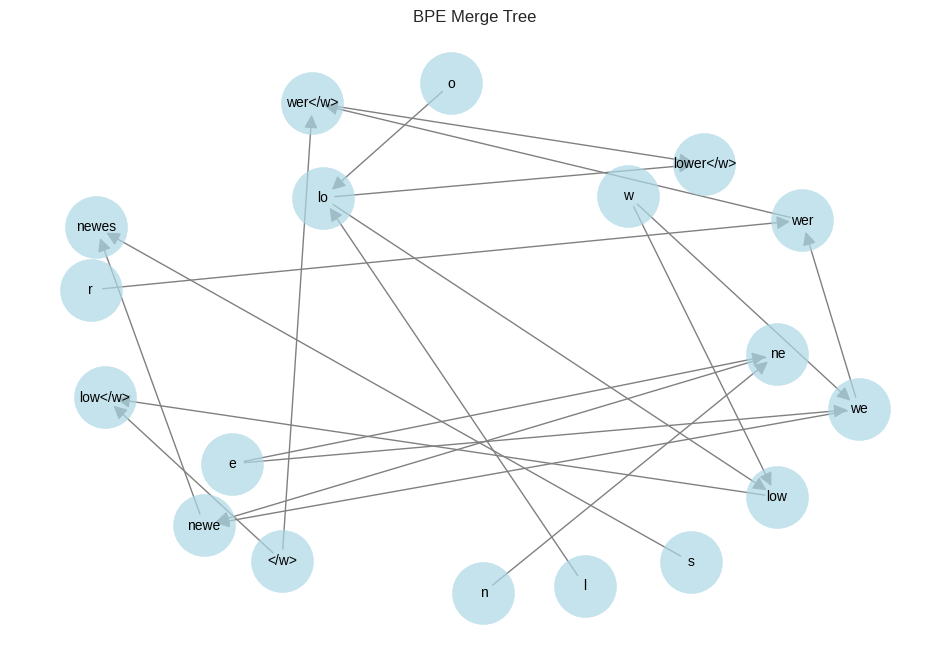

In [7]:
def visualize_merge_tree(merges):
    """Create a tree visualization of the merge operations."""
    G = nx.DiGraph()
    
    # Add nodes and edges for each merge
    for pair in merges:
        merged = ''.join(pair)
        G.add_node(pair[0])
        G.add_node(pair[1])
        G.add_node(merged)
        G.add_edge(pair[0], merged)
        G.add_edge(pair[1], merged)
    
    # Plot
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                           node_size=2000, alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=10)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                           arrows=True, arrowsize=20)
    
    plt.title("BPE Merge Tree")
    plt.axis('off')
    plt.show()

visualize_merge_tree(tokenizer.merges)

## 🧪 Test Our Tokenizer

Let's see how our tokenizer performs on new text.

In [8]:
# Test encoding/decoding
test_words = ["low", "lower", "lowest", "new", "newer", "newest"]

results = []
for word in test_words:
    tokens = tokenizer.encode(word)
    decoded = tokenizer.decode(tokens)
    results.append({
        'Original': word,
        'Tokens': tokens,
        'Decoded': decoded,
        'Match': word == decoded
    })

df = pd.DataFrame(results)
df

,Original,Tokens,Decoded,Match
0,low,[5],low,True
1,lower,[1],<unk>,False
2,lowest,[1],<unk>,False
3,new,[1],<unk>,False
4,newer,[1],<unk>,False
5,newest,[1],<unk>,False


## 🎯 Key Takeaways

1. **BPE learns subword units**: It finds the optimal balance between character and word-level tokenization
2. **Merges are hierarchical**: Each merge builds on previous ones, creating a tree structure
3. **End-of-word marker matters**: `</w>` helps the model learn word boundaries
4. **Vocabulary size is controllable**: More merges = larger vocabulary = more specific tokens

## 🔍 Next Steps

In the next notebook, we'll:
- Train on a larger dataset (TinyStories)
- Add proper handling of unknown tokens
- Implement byte-level BPE for handling Unicode
- Compare with OpenAI's tiktoken